In [7]:

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [13]:
# load csv files
users = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\app_users.csv")
entries = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\app_entries.csv")
icd_terms = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\ref_icd_terms.csv")
entry_symptoms = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\app_entry_symptoms.csv")
user_diagnoses = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\app_user_diagnoses.csv")
symptom_stats = pd.read_csv("D:\\Coding-Temple\\elre\\csv_files\\app_symptom_statistics.csv")

In [15]:
# From app.entry_symptoms
mean_conf = entry_symptoms["confidence"].mean()
median_conf = entry_symptoms["confidence"].median()
mode_conf = entry_symptoms["confidence"].mode()[0]


In [32]:
# Convert dates
entries["created_at"] = pd.to_datetime(entries["created_at"])
entry_symptoms["created_at"] = pd.to_datetime(entry_symptoms["created_at"])
symptom_stats["last_updated"] = pd.to_datetime(symptom_stats["last_updated"])

In [24]:
mean_conf

0.107

In [26]:
median_conf

0.543

In [28]:
mode_conf

0.107

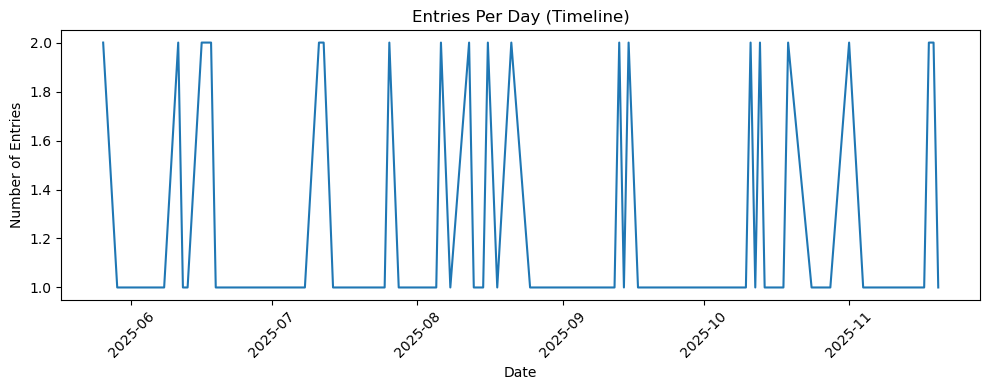

In [34]:
# 3. Line Chart (Entries over time)
# ---------------------------
entries_per_day = entries.groupby(entries["created_at"].dt.date).size()

plt.figure(figsize=(10,4))
plt.plot(entries_per_day.index, entries_per_day.values)
plt.title("Entries Per Day (Timeline)")
plt.xlabel("Date")
plt.ylabel("Number of Entries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


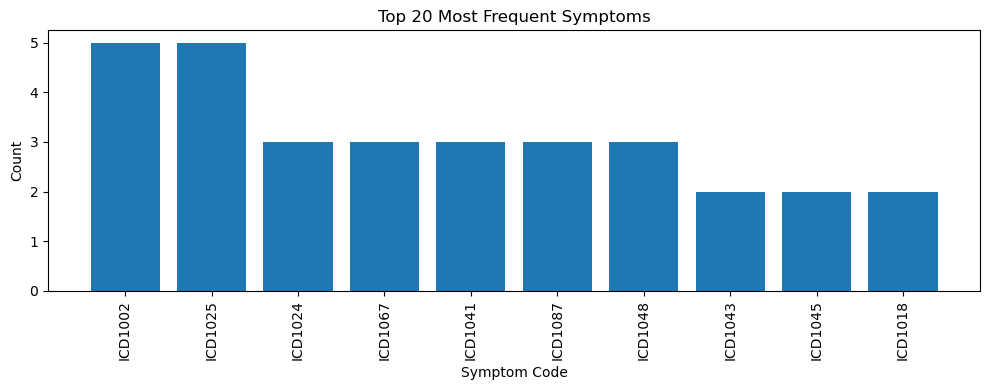

In [38]:
# 4. Bar Chart (Symptom Frequency)
# ---------------------------
symptom_freq = entry_symptoms["symptom_code"].value_counts().head(10)

plt.figure(figsize=(10,4))
plt.bar(symptom_freq.index, symptom_freq.values)
plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Symptom Code")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

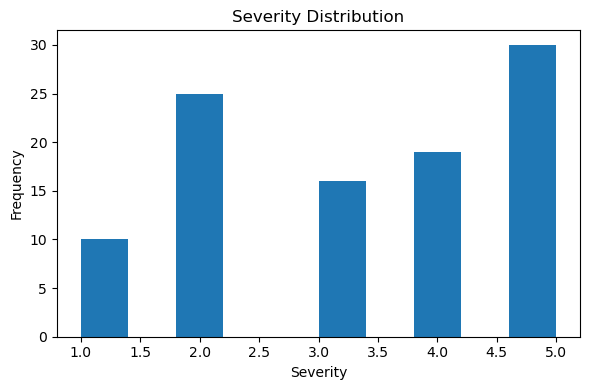

In [40]:
# 5. Histogram (Severity distribution)
# ---------------------------
plt.figure(figsize=(6,4))
plt.hist(entry_symptoms["severity"], bins=10)
plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [44]:
mean_severity = entry_symptoms["severity"].mean()
median_severity = entry_symptoms["severity"].median()
mode_severity = entry_symptoms["severity"].mode()[0]


In [46]:
print("\n=== SEVERITY ===")
print("Mean:", mean_severity)
print("Median:", median_severity)
print("Mode:", mode_severity)



=== SEVERITY ===
Mean: 3.34
Median: 3.0
Mode: 5


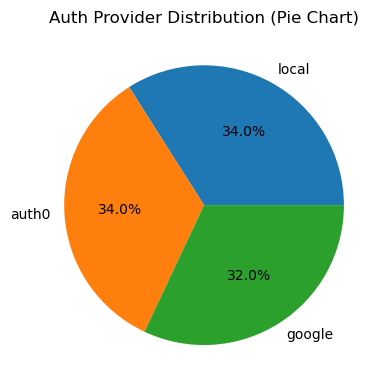

In [61]:
# Count providers
provider_counts = users["auth_provider"].value_counts()

# -----------------------------
# PIE CHART
# -----------------------------
plt.figure(figsize=(6, 4))
plt.pie(provider_counts.values, labels=provider_counts.index, autopct='%1.1f%%')
plt.title("Auth Provider Distribution (Pie Chart)")
plt.tight_layout()
plt.show()
